In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure 
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering, MeanShift
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score,rand_score,fowlkes_mallows_score, normalized_mutual_info_score
from sklearn.metrics import mean_squared_error
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv(r'C:\Users\user\Desktop\Country-data.csv')
data.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
data.shape

(167, 10)

In [4]:
data.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


# Data Visualization

## Selecting features excluding country (object)

In [6]:
X = data.columns[1:] 
y = data['country']

## Histograms for Feature Distributions

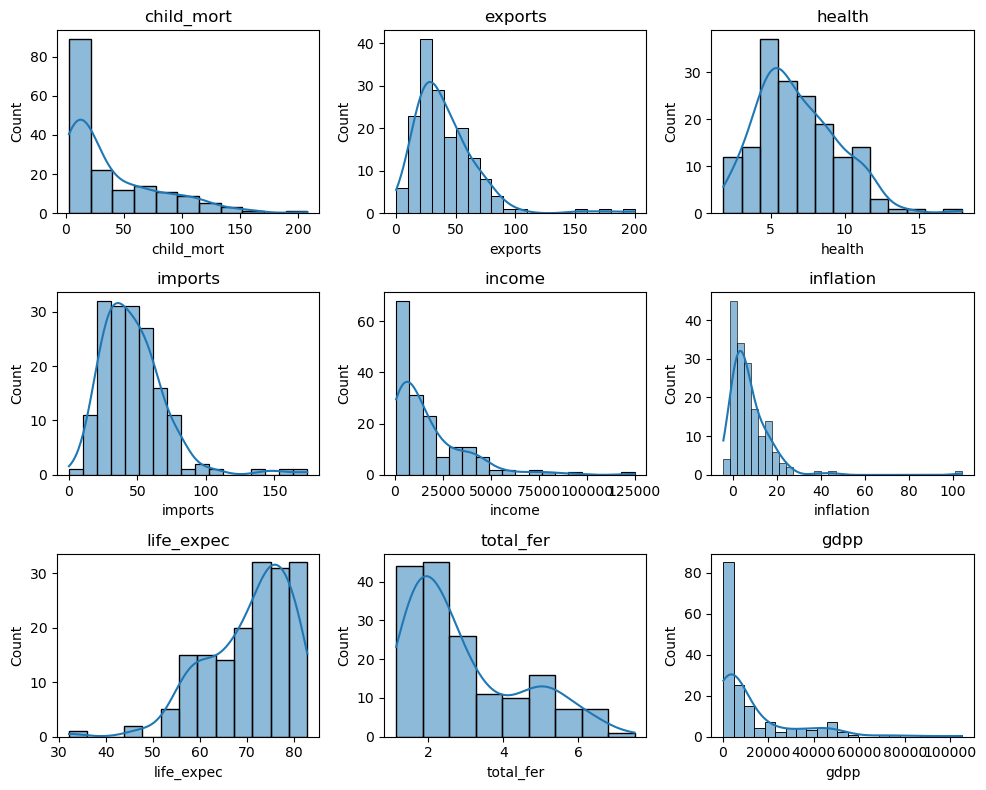

In [7]:
plt.figure(figsize=(10,8))
for i, x in enumerate(X):
    plt.subplot(3, 3, i+1)
    sns.histplot(data[x], kde = True)
    plt.title(x)
plt.tight_layout()
plt.show()

## BoxPlot for feature distribution

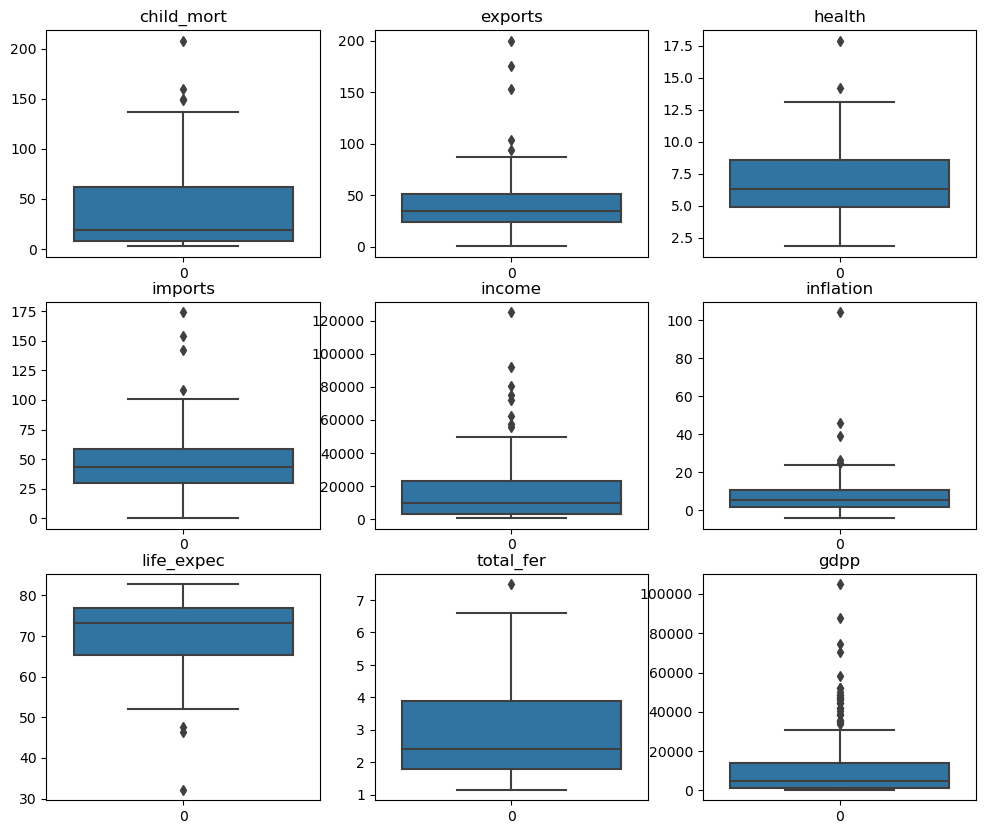

In [8]:
plt.figure(figsize=(12,10))

for i, x in enumerate(X):
    plt.subplot(3, 3, i+1)
    sns.boxplot(data[x])
    plt.title(x)
ylimits = plt.ylim()
plt.show()

## Outliers percentage based on distribution analysis

In [9]:
a = data.query(' child_mort > 140').index.tolist()
b = data.query('exports  > 90').index.tolist()
c = data.query('exports  > 90').index.tolist()
d = data.query('health  > 13').index.tolist()
e = data.query('imports  > 100').index.tolist()
f = data.query('income  > 50000').index.tolist()
g = data.query('inflation  > 25').index.tolist()
h = data.query('life_expec < 50').index.tolist()
i = data.query('total_fer  > 7').index.tolist()
j =data.query('gdpp > 32000').index.tolist()

In [10]:
outliers = a+b+c+d+e+f+g+h+i+j

In [11]:
outliers_percentage = (((data.shape[0])-len(outliers))/data.shape[0])*100
print(f'outliers_percentage: {outliers_percentage}%')

outliers_percentage: 62.27544910179641%


“The 67% outlier rate was obtained using a visual approach based on boxplots and histograms, where values outside the observed distribution range were considered outliers. However, this does not necessarily indicate abnormal or incorrect data, but rather reflects strong variability across features in the dataset.”

#  Correlation matrix

<Axes: >

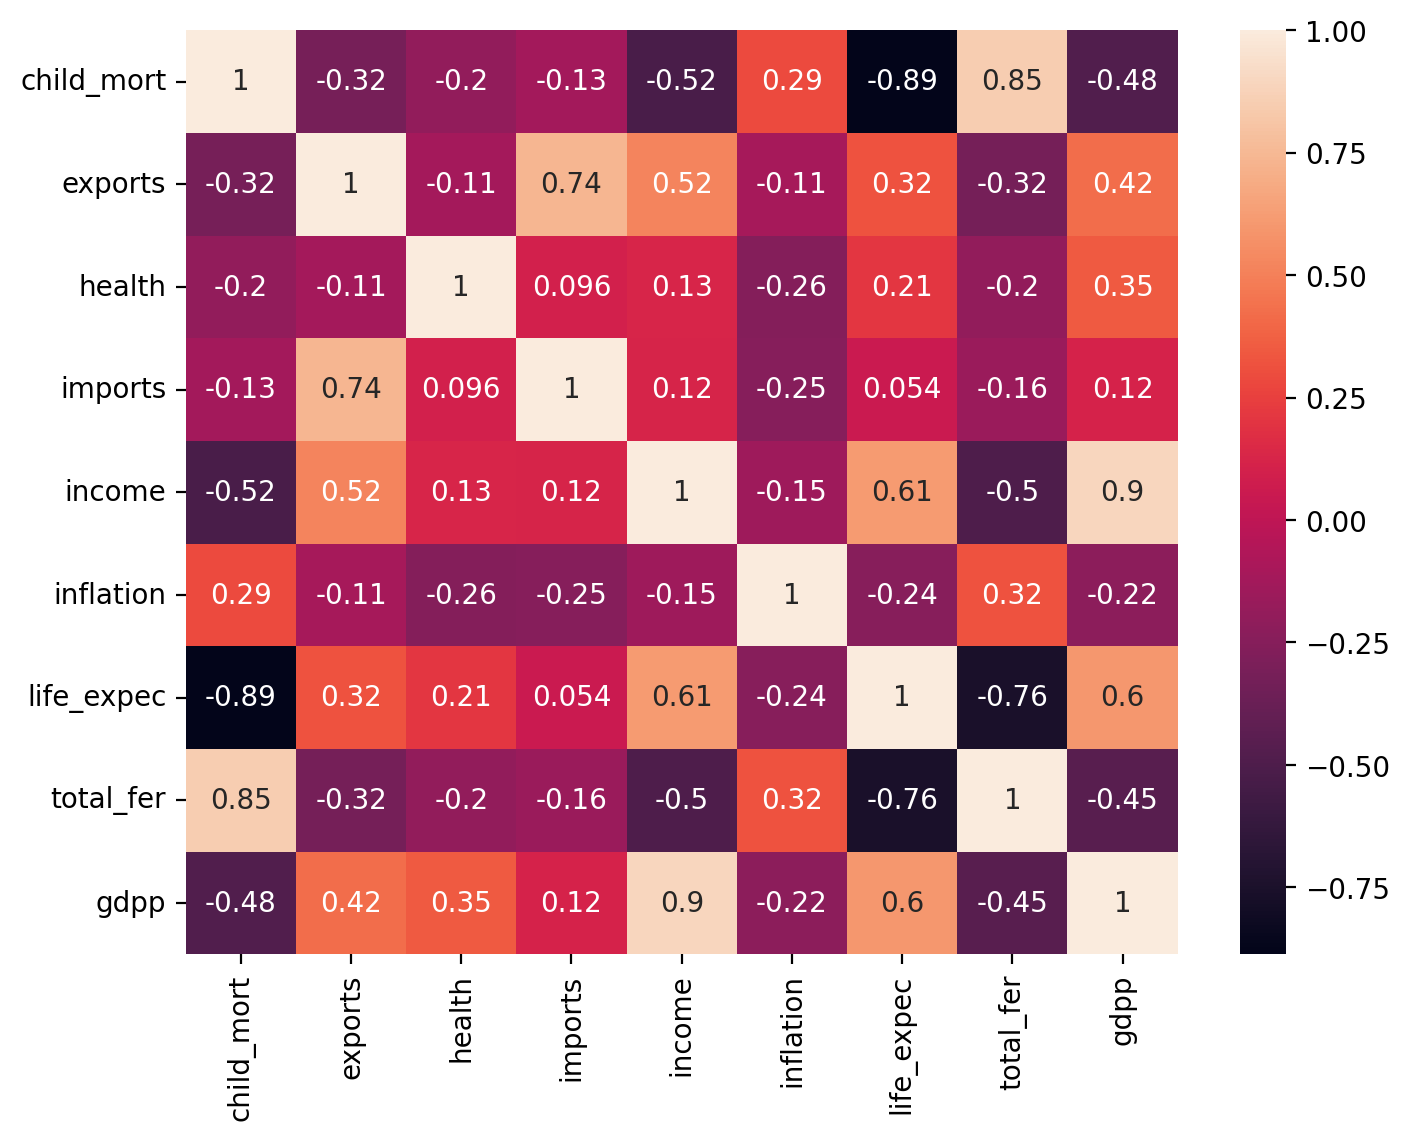

In [12]:
correlation_matrix = data.corr()
plt.figure(figsize=(8, 6), dpi = 200)
sns.heatmap(correlation_matrix, annot = True)

# Data Preprocessing

In [13]:
df = data.loc[:,X].values
df = StandardScaler().fit_transform(df)
df

array([[ 1.29153238, -1.13827979,  0.27908825, ..., -1.61909203,
         1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618, ...,  0.64786643,
        -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, ...,  0.67042323,
        -0.0384044 , -0.46537561],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ...,  0.28695762,
        -0.66120626, -0.63775406],
       [ 0.44841668, -0.40647827, -0.59727159, ..., -0.34463279,
         1.14094382, -0.63775406],
       [ 1.11495062, -0.15034774, -0.33801514, ..., -2.09278484,
         1.6246091 , -0.62954556]])

# Principal Component Analysis -PCA-

Text(0.5, 1.0, 'PCA - Explained Variance')

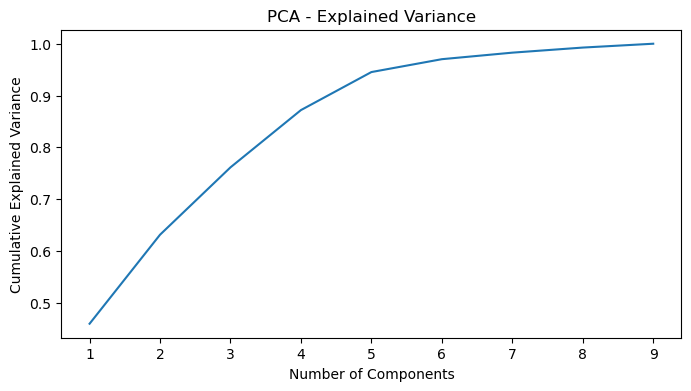

In [14]:
#Compute cumulative explained variance for different numbers of PCA components and plot the results

explained_variance = []

for i in range(1,10):
    pca = PCA(n_components = i)
    pca.fit(df)
    s = np.sum(pca.explained_variance_ratio_)
    explained_variance.append(s)

plt.figure(figsize=(8,4))
plt.plot(range(1,10), explained_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance')

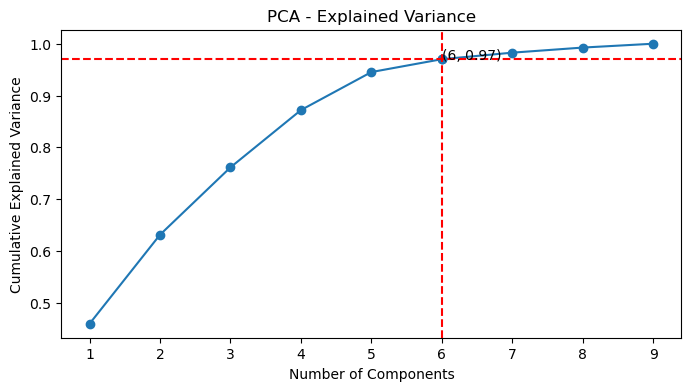

In [15]:
#Plot PCA cumulative explained variance and highlight the selected number of components (x=6) with reference lines and annotation
x = 6
y = explained_variance[x - 1] 

plt.figure(figsize=(8, 4))
plt.plot(range(1, 10), explained_variance, marker='o')

plt.axvline(x=x, linestyle='--', color = "red")  
plt.axhline(y=y, linestyle='--', color = 'red')  
plt.scatter(x, y)

plt.text(x, y, f'({x}, {y:.2f})')

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance')


plt.show()

Based on the explained variance curve, the optimal number of principal components was determined to be 6, after testing values from 1 to 9. This value provides a good balance between dimensionality reduction and information retention.

In [16]:
# Extarcting PCA features to reduce dimentionality 

pca = PCA(n_components=6)
principalComponents = pca.fit_transform(df)
df_pca = pd.DataFrame(data = principalComponents, columns = ['PC1','PC2','PC3','PC4','PC5','PC6'])
df_pca = pd.concat([df_pca, data[['country']]], axis = 1)
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,country
0,-2.913025,0.095621,-0.718118,1.005255,-0.158310,-0.254597,Afghanistan
1,0.429911,-0.588156,-0.333486,-1.161059,0.174677,0.084579,Albania
2,-0.285225,-0.455174,1.221505,-0.868115,0.156475,-0.401696,Algeria
3,-2.932423,1.695555,1.525044,0.839625,-0.273209,-0.547996,Angola
4,1.033576,0.136659,-0.225721,-0.847063,-0.193007,-0.206919,Antigua and Barbuda


In [17]:
df_pca = df_pca.drop('country', axis = 1)

In [18]:
principalComponents.shape

(167, 6)

# Algorithms

## KMeans

In [106]:
# tests different KMeans cluster numbers and evaluates them to find the optimal clustering solution.
params_grid = {
    'n_clusters': list(range(2, 10)),
}

results = []

for n_clusters in params_grid['n_clusters']:
        
        kmeans = KMeans(n_clusters=n_clusters)
        labels = kmeans.fit_predict(df_pca)
        silhouette = silhouette_score(df_pca, labels)
        calinski_harabasz = calinski_harabasz_score(df_pca, labels)
        davies_bouldin = davies_bouldin_score(df_pca, labels)
        
        results.append({
            'n_clusters':n_clusters,
            'silhouette_score': silhouette,
            'calinski_harabasz':calinski_harabasz,
            'davies_bouldin':davies_bouldin
            
        })


In [107]:
y_pred = pd.DataFrame(data = results)
y_pred

,n_clusters,silhouette_score,calinski_harabasz,davies_bouldin
0,2,0.296374,74.220815,1.266056
1,3,0.296805,69.979790,1.232525
2,4,0.316160,66.440233,0.999217
3,5,0.315614,61.968828,0.833715
4,6,0.272463,54.466569,1.176190
5,7,0.263020,58.362682,0.963087
6,8,0.252429,55.973825,1.128509
7,9,0.252120,54.924315,1.043363


In [108]:
y_score = y_pred.drop(['n_clusters'], axis = 1)
y_score 

,silhouette_score,calinski_harabasz,davies_bouldin
0,0.296374,74.220815,1.266056
1,0.296805,69.979790,1.232525
2,0.316160,66.440233,0.999217
3,0.315614,61.968828,0.833715
4,0.272463,54.466569,1.176190
5,0.263020,58.362682,0.963087
6,0.252429,55.973825,1.128509
7,0.252120,54.924315,1.043363


x = 1
plt.figure(figsize=(18, 4))
for i in y_score.columns:
    plt.subplot(1,3,x)
    plt.title(i)
    plt.plot(range(1,9), y_score[i], marker = 'o', color = 'red')
    x += 1 

### Elbow method

ymax: 429.49061754277915, ymin: 1079.7728411778328


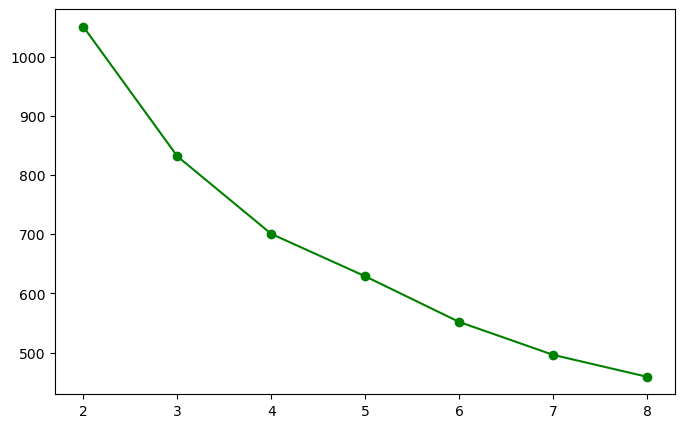

In [23]:
#Compute K-Means inertia for different numbers of clusters and plot the Elbow Method to choose the optimal k
score = []

for i in range(2,9):
     kmeans = KMeans(n_clusters=i)
     labels = kmeans.fit_predict(df)
     score.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,9), score, marker = 'o', color = 'green')

print(f'ymax: {plt.ylim()[0]}, ymin: {plt.ylim()[1]}')

Using both approaches (evaluation metrics and the elbow method), we can conclude that the optimal number of clusters for KMeans is 5, as it provides the best balance between cluster quality and variance reduction.

# K-Means clustering with 5 clusters based on "Silhouette and Calincki score" and Elbow mathod

In [114]:
# Apply K-Means clustering with 5 clusters and generate cluster labels for each data point
kmeans = KMeans(n_clusters=5, n_init=10, random_state = 42)
labels = kmeans.fit_predict(df)
labels

array([0, 2, 2, 0, 2, 2, 2, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 0, 2, 2, 2, 0,
       2, 1, 2, 0, 0, 2, 0, 1, 2, 0, 0, 2, 2, 2, 0, 0, 0, 2, 0, 2, 1, 1,
       1, 2, 2, 2, 2, 0, 0, 2, 2, 1, 1, 0, 0, 2, 1, 0, 1, 2, 2, 0, 0, 2,
       0, 2, 1, 2, 2, 2, 0, 1, 1, 1, 2, 1, 2, 2, 0, 0, 1, 2, 0, 2, 2, 0,
       0, 2, 2, 4, 2, 0, 0, 2, 2, 0, 4, 0, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2,
       1, 1, 0, 3, 1, 2, 0, 2, 2, 2, 2, 2, 1, 1, 2, 2, 0, 2, 2, 0, 2, 2,
       0, 4, 2, 1, 0, 0, 1, 1, 2, 2, 0, 2, 1, 1, 2, 0, 2, 0, 0, 2, 2, 2,
       2, 0, 2, 1, 1, 1, 2, 2, 2, 2, 2, 0, 0])

In [115]:
data_kmeans5 = data.copy()
data_kmeans5['labels'] = labels

In [116]:
data_kmeans5.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,labels
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


In [126]:
fig = px.choropleth(data_kmeans5,
                    locations='country', 
                    locationmode='country names', 
                    color='labels',
                    hover_name='country',
                    title='Countries by Clusters')
fig.show()

In [118]:
clust_freq = data_kmeans6.groupby('labels').mean() 
clust_freq['Freq'] = data_kmeans6['labels'].value_counts().sort_index()
clust_freq

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Freq
labels,,,,,,,,,,
0,90.793617,29.661915,6.462553,43.680851,3870.702128,9.951809,59.212766,4.974043,1900.255319,47
1,5.181250,46.118750,9.088437,40.584375,44021.875000,2.513844,80.081250,1.788437,42118.750000,32
2,21.614286,40.976060,6.169048,47.518642,12801.071429,7.618857,73.004762,2.277619,6581.809524,84
3,130.000000,25.300000,5.070000,17.400000,5150.000000,104.000000,60.500000,5.840000,2330.000000,1
4,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000,57566.666667,3


The K-Means results (k = 5) show that countries are grouped based on life expectancy, income, exports, and imports.

Developed countries (e.g., the United States, Canada, Australia, and Europe) form one cluster. Another cluster includes lower-income regions such as North Africa, South America, and parts of Asia. Very poor countries (e.g., Yemen) form a separate group.

Nigeria appears in its own cluster. Finally, very rich countries like Luxembourg form a small cluster that may require zooming in to be clearly visible on the map "it's in yellow color".

# K-Means clustering with 4 clusters based on "Davies_Bouldin score"

In [119]:
# Apply K-Means clustering with 4 clusters and generate cluster labels for each data point
kmeans = KMeans(n_clusters=4, n_init=10, random_state = 42)
labels = kmeans.fit_predict(df)
labels

array([1, 0, 0, 1, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 1,
       0, 2, 0, 1, 1, 0, 1, 2, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 2, 0,
       2, 0, 0, 0, 0, 1, 1, 0, 0, 2, 2, 1, 1, 0, 2, 1, 2, 0, 0, 1, 1, 0,
       1, 0, 2, 0, 0, 0, 1, 2, 2, 2, 0, 2, 0, 0, 1, 1, 2, 0, 1, 0, 0, 1,
       1, 0, 0, 3, 0, 1, 1, 0, 0, 1, 3, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       2, 2, 1, 1, 2, 0, 1, 0, 0, 0, 0, 0, 2, 2, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 3, 0, 2, 0, 1, 2, 2, 0, 0, 1, 0, 2, 2, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1])

In [120]:
data_kmeans4 = data.copy()
data_kmeans4['labels'] = labels

In [121]:
data_kmeans4.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,labels
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


In [127]:
fig = px.choropleth(data_kmeans4,
                    locations='country', 
                    locationmode='country names', 
                    color='labels',
                    hover_name='country',
                    title='Countries by Clusters')
fig.show()

In [125]:
clust_freq = data_kmeans4.groupby('labels').mean() 
clust_freq['Freq'] = data_kmeans4['labels'].value_counts().sort_index()
clust_freq

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Freq
labels,,,,,,,,,,
0,21.389655,41.290678,6.235862,48.038689,12968.620690,7.413460,72.935632,2.286552,6919.103448,87
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,47
2,4.953333,45.826667,9.168667,39.736667,45250.000000,2.742200,80.376667,1.795333,43333.333333,30
3,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000,57566.666667,3


After applying K-Means with 4 clusters based on the Davies–Bouldin score, we observe that the results are largely similar. The main difference is that Nigeria is no longer isolated and is now grouped with other African countries, which appears more realistic.